In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "ushape.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "agarwalronakagarwal/unshape-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_3959/392912221.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 2.81k/2.81k [00:00<00:00, 3.58MB/s]

First 5 records:         X       Y  class
0  0.0316  0.9870    0.0
1  2.1200 -0.0462    1.0
2  0.8820 -0.0758    0.0
3 -0.0551 -0.0373    1.0
4  0.8300 -0.5390    1.0


In [ ]:
df.head()

,X,Y,class
0,0.0316,0.9870,0.0
1,2.1200,-0.0462,1.0
2,0.8820,-0.0758,0.0
3,-0.0551,-0.0373,1.0
4,0.8300,-0.5390,1.0


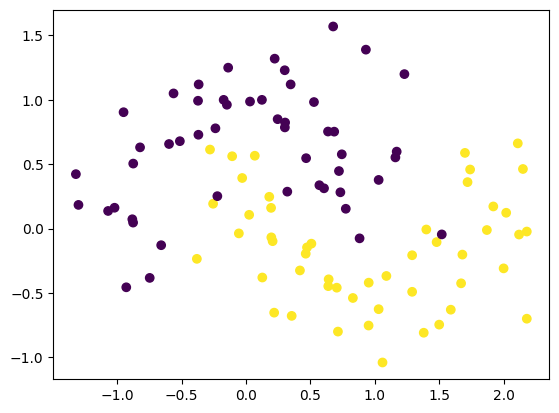

In [ ]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [ ]:
X=df.iloc[:,0:2].values
y=df.iloc[:,-1].values

In [ ]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [ ]:
model=Sequential()
model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.get_weights()

[array([[-0.35639617, -0.28141463,  1.4654647 ,  0.32083884, -0.6281    ,
          0.7060711 ,  1.4921252 , -1.691743  ,  0.9057357 , -0.14413309],
        [ 1.6872425 , -1.5465789 , -1.5450634 , -0.16387424, -0.66724765,
         -0.80950147,  0.50227445, -1.2784168 , -1.9116459 , -0.17566699]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.46669874, -0.55022025, -0.19420698,  0.10380341,  0.26788917,
         -0.35912013, -0.17468035, -0.32526878, -0.11454614, -0.5301576 ],
        [ 0.9609133 ,  0.9641373 ,  0.37955582, -0.66163844, -0.3900838 ,
         -0.28674868,  0.33592913,  0.25896555,  0.37463716,  0.84115475],
        [ 0.3091784 ,  0.83809227,  0.5330023 ,  0.7318632 ,  0.25193456,
          0.4170591 , -0.33857384,  0.54187113, -0.9481662 ,  0.39839402],
        [-0.07719581, -0.28941232, -0.7888105 , -0.09200857,  0.00925363,
          0.35390383,  0.49753374,  0.05343365, -0.63772357,  0.9087282 ],
        [ 0.21246

In [ ]:
initial_weights=model.get_weights()

In [ ]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [ ]:
model.get_weights()

[array([[-0.35639617, -0.28141463,  1.4654647 ,  0.32083884, -0.6281    ,
          0.7060711 ,  1.4921252 , -1.691743  ,  0.9057357 , -0.14413309],
        [ 1.6872425 , -1.5465789 , -1.5450634 , -0.16387424, -0.66724765,
         -0.80950147,  0.50227445, -1.2784168 , -1.9116459 , -0.17566699]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.46669874, -0.55022025, -0.19420698,  0.10380341,  0.26788917,
         -0.35912013, -0.17468035, -0.32526878, -0.11454614, -0.5301576 ],
        [ 0.9609133 ,  0.9641373 ,  0.37955582, -0.66163844, -0.3900838 ,
         -0.28674868,  0.33592913,  0.25896555,  0.37463716,  0.84115475],
        [ 0.3091784 ,  0.83809227,  0.5330023 ,  0.7318632 ,  0.25193456,
          0.4170591 , -0.33857384,  0.54187113, -0.9481662 ,  0.39839402],
        [-0.07719581, -0.28941232, -0.7888105 , -0.09200857,  0.00925363,
          0.35390383,  0.49753374,  0.05343365, -0.63772357,  0.9087282 ],
        [ 0.21246

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
history=model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - accuracy: 0.4750 - loss: 0.7782 - val_accuracy: 0.5000 - val_loss: 0.7766
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5125 - loss: 0.7320 - val_accuracy: 0.5500 - val_loss: 0.7337
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5250 - loss: 0.6876 - val_accuracy: 0.5500 - val_loss: 0.6956
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5375 - loss: 0.6508 - val_accuracy: 0.6000 - val_loss: 0.6614
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5750 - loss: 0.6171 - val_accuracy: 0.6500 - val_loss: 0.6294
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6000 - loss: 0.5882 - val_accuracy: 0.7000 - val_loss: 0.6009
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6750 - loss: 0.5646 - val_accuracy: 0.7500 - val_loss: 0.5754
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8125 - loss: 0.5421 - val_accuracy: 0.8500 - val_loss

In [ ]:
model.get_weights()

[array([[-0.50082755, -0.2317516 ,  1.5513475 ,  0.24789055, -0.52599585,
          0.77792436,  1.4432524 , -1.8814461 ,  0.9687645 , -0.06748735],
        [ 1.7102904 , -1.632962  , -1.5165194 , -0.21195592, -0.6660095 ,
         -0.7529339 ,  0.6229675 , -1.2055514 , -1.9526533 , -0.306949  ]],
       dtype=float32),
 array([ 0.01323139,  0.11556534,  0.04189261, -0.02202487, -0.08266027,
        -0.11275581, -0.01523957,  0.00350623,  0.08253168,  0.04187802],
       dtype=float32),
 array([[ 0.45418736, -0.6307485 , -0.06597429,  0.16505289,  0.44214457,
         -0.35912013, -0.00435904, -0.47714978, -0.11454614, -0.73637694],
        [ 0.9587303 ,  0.801087  ,  0.5516274 , -0.7206766 , -0.40836698,
         -0.28674868,  0.37223458,  0.30420324,  0.37463716,  0.9016762 ],
        [ 0.2976907 ,  0.8682478 ,  0.58107287,  0.71119815,  0.19559819,
          0.4170591 , -0.41574848,  0.60469437, -0.9481662 ,  0.4150856 ],
        [-0.10948836, -0.23406799, -0.744186  , -0.11070424, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

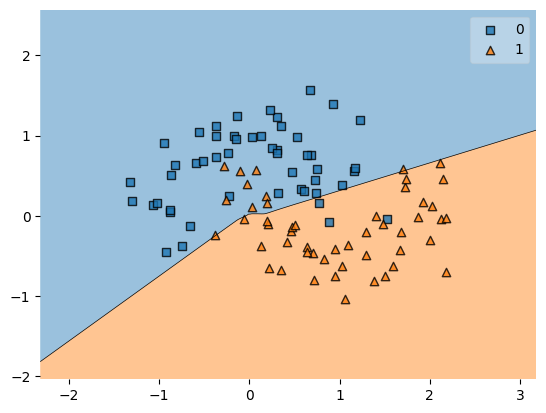

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype(int),clf=model)

In [ ]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.02333831692650413)

In [ ]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.02497376968258726)

In [ ]:
model=Sequential()
model.add(Dense(10,activation='tanh',input_dim=2,kernel_initializer='glorot_normal'))
model.add(Dense(10,activation='tanh',kernel_initializer='glorot_normal'))
model.add(Dense(10,activation='tanh',kernel_initializer='glorot_normal'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.get_weights()

[array([[ 0.3032253 ,  0.2984665 ,  0.4137475 , -0.02737109, -0.16865896,
          0.42773968,  0.07741489,  0.6013631 , -0.6377973 , -0.78731614],
        [ 0.15008073, -0.12764189, -0.15933703, -0.15216427,  0.5972047 ,
         -0.56895965, -0.5342763 ,  0.07054992,  0.7565901 , -0.7138361 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.21194987,  0.44331643,  0.42470607, -0.43972167, -0.32844916,
          0.4301005 ,  0.04557626,  0.36233622, -0.10560382,  0.43792745],
        [-0.0493794 , -0.532433  ,  0.2412584 ,  0.48172328,  0.19196354,
         -0.4099433 ,  0.22843753, -0.04223049,  0.21592434, -0.62050563],
        [-0.33200166,  0.37661085,  0.18514545, -0.44525826, -0.7164659 ,
         -0.18780814, -0.1715038 ,  0.09041554, -0.19792603,  0.12138849],
        [-0.26461217,  0.046043  , -0.06794375,  0.18545312,  0.65872514,
          0.03494188,  0.48545912,  0.3911013 , -0.07776274,  0.14403138],
        [-0.54870

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
history=model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.8250 - loss: 0.6295 - val_accuracy: 0.9000 - val_loss: 0.5920
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8500 - loss: 0.6068 - val_accuracy: 0.8500 - val_loss: 0.5650
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8500 - loss: 0.5877 - val_accuracy: 0.8000 - val_loss: 0.5394
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8375 - loss: 0.5687 - val_accuracy: 0.8500 - val_loss: 0.5154
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8250 - loss: 0.5502 - val_accuracy: 0.8500 - val_loss: 0.4932
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8125 - loss: 0.5350 - val_accuracy: 0.8500 - val_loss: 0.4724
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8125 - loss: 0.5202 - val_accuracy: 0.8500 - val_loss: 0.4536
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8125 - loss: 0.5054 - val_accuracy: 0.8500 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


<Axes: >

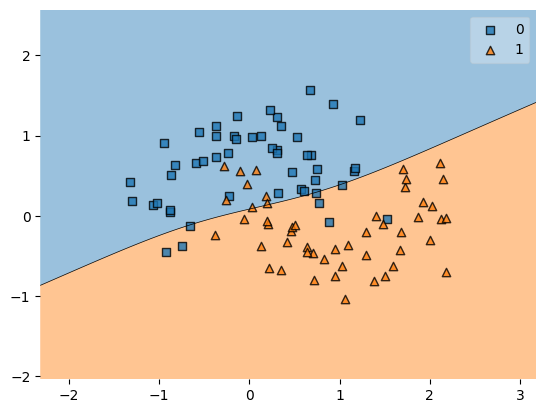

In [ ]:
plot_decision_regions(X,y.astype(int),clf=model)